# Particle Trajectories for Different Discrepancy Geometries

This notebook generates `fig:gradflow-particle-objective-geometries`.  Starting from the same empirical model and target clouds, we draw four qualitative descent geometries: exact OT displacement rays, an MMD force, an entropic Sinkhorn-divergence force, and a normalized drifting field.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.collections import LineCollection
import ot

NAME = "gradflow-particle-objective-geometries"
out = figure_dir(NAME)
rng = np.random.default_rng(23)

The panels are small schematic particle flows, not benchmark comparisons.  The point is that the discrepancy changes the geometry of the velocity field.

In [2]:
def cloud(center, cov, n):
    return rng.multivariate_normal(center, cov, n)

x0 = np.vstack([
    cloud([-1.05, -0.28], [[0.028, 0.006], [0.006, 0.040]], 13),
    cloud([-0.80,  0.56], [[0.035, -0.006], [-0.006, 0.030]], 12),
])
y = np.vstack([
    cloud([0.65, -0.52], [[0.034, 0.004], [0.004, 0.030]], 13),
    cloud([1.05,  0.42], [[0.030, -0.008], [-0.008, 0.046]], 12),
])
n = len(x0)
a = np.ones(n)/n
C = ot.dist(x0, y)
P = ot.emd(a, a, C)
ym = y[P.argmax(axis=1)]
all_points = np.vstack([x0, y])
xlim, ylim = padded_limits(all_points, pad=0.15)

In [3]:
def kernel_field(X, Y, eps=0.24, normalize=False):
    diff = Y[None, :, :] - X[:, None, :]
    K = np.exp(-np.sum(diff**2, axis=-1) / (2 * eps))
    num = (K[:, :, None] * diff).sum(axis=1)
    if normalize:
        return num / (K.sum(axis=1, keepdims=True) + 1e-12)
    return num / len(Y)

def sinkhorn_barycentric_field(X, reg=0.055):
    aX = np.ones(len(X)) / len(X)
    bY = np.ones(len(y)) / len(y)
    Cxy = ot.dist(X, y)
    Pxy = ot.sinkhorn(aX, bY, Cxy, reg=reg, numItermax=220, stopThr=1e-7)
    bary_y = Pxy @ y / (aX[:, None] + 1e-15)
    Cxx = ot.dist(X, X)
    Pxx = ot.sinkhorn(aX, aX, Cxx, reg=reg, numItermax=220, stopThr=1e-7)
    bary_x = Pxx @ X / (aX[:, None] + 1e-15)
    return (bary_y - X) - 0.50 * (bary_x - X)

def simulate(field, steps=48, dt=0.20, speed_cap=1.7):
    traj = np.zeros((steps+1, n, 2))
    traj[0] = x0
    X = x0.copy()
    for k in range(steps):
        V = field(X)
        speed = np.linalg.norm(V, axis=1).max()
        if speed > 1e-9:
            V = V / max(speed, speed_cap)
        X = X + dt * V
        traj[k+1] = X
    return traj

traj_ot = np.stack([(1-t)*x0 + t*ym for t in np.linspace(0, 1, 49)], axis=0)
traj_mmd = simulate(lambda X: 2.5 * (kernel_field(X, y, eps=0.30, normalize=False) - kernel_field(X, X, eps=0.30, normalize=False)), steps=52, dt=0.22, speed_cap=1.7)
traj_sinkhorn = simulate(lambda X: sinkhorn_barycentric_field(X, reg=0.055), steps=48, dt=0.24, speed_cap=1.45)
traj_drift = simulate(lambda X: 1.9 * (kernel_field(X, y, eps=0.23, normalize=True) - 0.82 * kernel_field(X, X, eps=0.23, normalize=True)), steps=52, dt=0.23, speed_cap=1.55)

/Users/gpeyre/miniconda3/envs/py314/lib/python3.14/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


In [4]:
def draw_traj(traj, filename):
    fig, ax = plt.subplots(figsize=(2.30, 1.82))
    for i in range(n):
        pts = traj[:, i]
        segments = np.stack([pts[:-1], pts[1:]], axis=1)
        cols = [(*interp_color(k/(len(pts)-2)), 0.39) for k in range(len(pts)-1)]
        ax.add_collection(LineCollection(segments, colors=cols, linewidths=0.56, zorder=1))
    ax.scatter(y[:,0], y[:,1], s=DIRAC_MARKER_SIZE * 0.47, marker="o", color=BLUE, edgecolor="none", linewidth=0, alpha=0.62, zorder=2)
    ax.scatter(traj[0,:,0], traj[0,:,1], s=DIRAC_MARKER_SIZE * 0.50, marker="o", color=RED, edgecolor="none", linewidth=0, zorder=3)
    ax.scatter(traj[-1,:,0], traj[-1,:,1], s=DIRAC_MARKER_SIZE * 0.54, marker="o", color=VIOLET, edgecolor="none", linewidth=0, zorder=4)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.055)
    plt.close(fig)

for traj, filename in [
    (traj_ot, "ot-rays.pdf"),
    (traj_mmd, "mmd-force.pdf"),
    (traj_sinkhorn, "sinkhorn-divergence.pdf"),
    (traj_drift, "drifting-field.pdf"),
]:
    draw_traj(traj, filename)
# Keep the previous filename as an archive alias, but the LaTeX paper now uses sinkhorn-divergence.pdf.
draw_traj(traj_sinkhorn, "local-density.pdf")

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


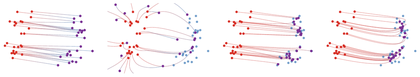

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/gradflow-particle-objective-geometries.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gradflow-particle-objective-geometries.png")
display(Image(filename=str(_thumb)))
